In [12]:
# import nbformat
# from google.colab import files

# nb_path = "/content/drive/MyDrive/Colab Notebooks/YA_MS3.ipynb"   # change to your notebook name

# nb = nbformat.read(nb_path, as_version=4)

# # 🔥 Remove widget metadata ONLY
# if "widgets" in nb["metadata"]:
#     del nb["metadata"]["widgets"]

# nbformat.write(nb, nb_path)

# print("✅ Cleaned notebook (outputs preserved)")

# files.download(nb_path)

# DEtection TRansformer (DETR)

Pros:

1. No region proposal tuning
2. Sigle stage pipeline
3. Single loss function

Cons:

1.   Data hungry
2.   Strugles with small objects
3.   Too big to fit in mobile


Requires:

> The follicle data be loaded into drive or directly into colab runtime environment.
> The fine-tuned model is in my drive. I can share if needed (to avoid re-trianing).

Key Param:

The number of decoder queries is set to 100. Given that the median number of objects per image is 12, this value can be reduced to help minimize overlapping predictions.



In [13]:
import os
import xml.etree.ElementTree as ET
from dataclasses import dataclass
from typing import List, Dict, Any

import torch
from torch.utils.data import Dataset
from PIL import Image, ImageDraw, ImageFont

from transformers import (
    DetrImageProcessor,
    DetrForObjectDetection,
    TrainingArguments,
    Trainer
)

import pandas as pd
import matplotlib.pyplot as plt
import json
from transformers import DetrConfig

import cv2
import numpy as np
from torch.utils.data import Dataset
import albumentations as A
from typing import List, Optional


import torch.nn.functional as F

from scipy.optimize import linear_sum_assignment

from torchvision.ops import (
    box_convert,
    generalized_box_iou
)

import torch
from torch.utils.data import DataLoader
from transformers import Trainer
from collections import Counter
from torchvision.ops import box_convert

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
!cp -r /content/drive/MyDrive/data /content/


# CONFIG

In [16]:
# ============================================================
# CONFIG: setting params
# ============================================================

@dataclass
class Config:
    # paths
    image_dir: str = "/content/data/Images"
    annot_dir: str = "/content/data/Annotations"
    output_dir: str = "./detr_voc_finetuned"

    # model
    pretrained_model_name: str = "facebook/detr-resnet-50"
    image_size: int = 800
    num_queries: int = 100

    # classes
    class_names: Optional[List[str]] = None

    # training
    per_device_train_batch_size: int = 2
    per_device_eval_batch_size: int = 2
    gradient_accumulation_steps: int = 4 #effective batch size=8
    num_train_epochs: int = 30

    # optimizer
    learning_rate: float = 1e-4
    lr_backbone: float = 1e-5 # we don't want Resnet change too much
    weight_decay: float = 1e-4
    warmup_steps: int = 500
    lr_scheduler_type: str = "cosine"

    # dataloader/checkpoint
    num_workers: int = 2 # dataloader cpu
    save_total_limit: int = 2 # keep only 2

    # imbalance handling: custom flags, not built into DETR
    use_weighted_sampler: bool = True
    use_class_weighted_loss: bool = True
    class_weight_alpha: float = 1.0

    # augmentation
    use_augmentation: bool = True

    # evaluation
    iou_threshold: float = 0.5
    score_threshold: float = 0.05

    def __post_init__(self):
        if self.class_names is None:
            self.class_names = [
                "premium",
                "single",
                "undersize",
                "abnormal",
            ]

        self.label2id = {
            name: i for i, name in enumerate(self.class_names)
        }

        self.id2label = {
            i: name for i, name in enumerate(self.class_names)
        }

        self.num_labels = len(self.class_names)


cfg = Config()

# Pascal VOC class ids must start from 0
id2label = {i: name for i, name in enumerate(cfg.class_names)}
label2id = {name: i for i, name in id2label.items()}


# training and validation split

In [17]:
# load training and validation file names
train_files =[]
val_files = []
with open('/content/data/ImageSets/Main/train.txt') as f:
    lines = f.readlines()
    train_files =[fnm[:-1] for fnm in lines]

with open('/content/data/ImageSets/Main/val.txt') as f:
    lines = f.readlines()
    val_files =[fnm[:-1] for fnm in lines]

# XML Parser

In [18]:
def scale_box_xyxy(box, scale, img_w, img_h):
    x1, y1, x2, y2 = box

    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2
    bw = (x2 - x1) * scale
    bh = (y2 - y1) * scale

    new_box = [
        cx - bw / 2,
        cy - bh / 2,
        cx + bw / 2,
        cy + bh / 2,
    ]

    return clip_box_xyxy(new_box, img_w, img_h)


def downscale_box_xyxy(box, scale):
    x1, y1, x2, y2 = box

    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2
    bw = (x2 - x1) / scale
    bh = (y2 - y1) / scale

    return [
        cx - bw / 2,
        cy - bh / 2,
        cx + bw / 2,
        cy + bh / 2,
    ]


def downscale_boxes_xyxy(boxes, scale):
    boxes = boxes.clone()

    cx = (boxes[:, 0] + boxes[:, 2]) / 2
    cy = (boxes[:, 1] + boxes[:, 3]) / 2
    bw = (boxes[:, 2] - boxes[:, 0]) / scale
    bh = (boxes[:, 3] - boxes[:, 1]) / scale

    boxes[:, 0] = cx - bw / 2
    boxes[:, 1] = cy - bh / 2
    boxes[:, 2] = cx + bw / 2
    boxes[:, 3] = cy + bh / 2

    return boxes

In [19]:

# ============================================================
# XML Parser and bbox fixer
# ============================================================

def clip_box_xyxy(box, width, height):
    x1, y1, x2, y2 = box
    x1 = max(0.0, min(float(x1), width - 1))
    y1 = max(0.0, min(float(y1), height - 1))
    x2 = max(0.0, min(float(x2), width - 1))
    y2 = max(0.0, min(float(y2), height - 1))
    return [x1, y1, x2, y2]

def is_valid_xyxy(box):
    x1, y1, x2, y2 = box
    return (x2 > x1) and (y2 > y1)
#coco style bounding box
def xyxy_to_xywh(box):
    x1, y1, x2, y2 = box
    return [x1, y1, x2 - x1, y2 - y1]

def parse_voc_xml(xml_path: str, label2id: Dict[str, int]) -> Dict[str, Any]:
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.findtext("filename")
    size = root.find("size")
    width = int(size.findtext("width"))
    height = int(size.findtext("height"))

    objects = []
    for obj in root.findall("object"):
        name = obj.findtext("name")
        if name is None:
            name = obj.findtext("class")
        if name is None:
            continue

        name = name.strip().lower()
        if name not in label2id:
            continue

        bndbox = obj.find("bndbox")
        if bndbox is None:
            continue

        xmin = float(bndbox.findtext("xmin"))
        ymin = float(bndbox.findtext("ymin"))
        xmax = float(bndbox.findtext("xmax"))
        ymax = float(bndbox.findtext("ymax"))

        # Repair reversed coordinates
        x1, x2 = sorted([xmin, xmax])
        y1, y2 = sorted([ymin, ymax])

        # Clip to XML-declared image size
        x1 = max(0.0, min(x1, width - 1))
        y1 = max(0.0, min(y1, height - 1))
        x2 = max(0.0, min(x2, width - 1))
        y2 = max(0.0, min(y2, height - 1))

        if x2 <= x1 or y2 <= y1:
            continue

        difficult = obj.findtext("difficult")
        difficult = int(difficult) if difficult is not None else 0

        objects.append({
            "name": name,
            "class_id": label2id[name],
            "bbox_xyxy": [x1, y1, x2, y2],
            "difficult": difficult,#how difficult is the object to detect
        })

    return {
        "filename": filename,
        "width": width,
        "height": height,
        "objects": objects,
    }



# Data Augmentation

In [20]:
#Augmentation
train_transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.2),

        A.Rotate(
            limit=15,
            border_mode=cv2.BORDER_CONSTANT,
            p=0.4
        ),

        A.RandomBrightnessContrast(
            brightness_limit=0.15,
            contrast_limit=0.15,
            p=0.4
        ),

        A.CLAHE(
            clip_limit=2.0,
            tile_grid_size=(8, 8),
            p=0.3
        ),

        A.Sharpen(
            alpha=(0.1, 0.25),
            lightness=(0.8, 1.2),
            p=0.25
        ),

        A.GaussNoise(p=0.15),
    ],
    bbox_params=A.BboxParams(
        format="pascal_voc",          # [xmin, ymin, xmax, ymax]
        label_fields=["class_labels"],
        min_visibility=0.3
    )
)
val_transform = None


# Dataset Class

In [21]:
class PascalVOCDataset(Dataset):
    def __init__(
        self,
        image_dir,
        annot_dir,
        processor,
        label2id,
        split,
        transform=None,
        box_scale=1.0,
    ):
        self.image_dir = image_dir
        self.annot_dir = annot_dir
        self.processor = processor
        self.label2id = label2id
        self.split = set(split)
        self.transform = transform
        self.box_scale = box_scale

        self.xml_files = sorted([
            f for f in os.listdir(annot_dir)
            if f.endswith(".xml") and os.path.splitext(f)[0] in self.split
        ])

    def __len__(self):
        return len(self.xml_files)

    def __getitem__(self, idx):
        xml_file = self.xml_files[idx]
        xml_path = os.path.join(self.annot_dir, xml_file)

        parsed = parse_voc_xml(xml_path, self.label2id)

        image_filename = parsed["filename"]
        image_path = os.path.join(self.image_dir, image_filename)

        if not os.path.exists(image_path):
            stem = os.path.splitext(xml_file)[0]
            found = False
            for ext in [".jpg", ".jpeg", ".png", ".bmp"]:
                alt_path = os.path.join(self.image_dir, stem + ext)
                if os.path.exists(alt_path):
                    image_path = alt_path
                    found = True
                    break
            if not found:
                raise FileNotFoundError(f"Image not found for XML: {xml_path}")

        image = Image.open(image_path).convert("RGB")
        width, height = image.size

        boxes_xyxy = []
        class_labels = []

        for obj in parsed["objects"]:
            box_xyxy = clip_box_xyxy(obj["bbox_xyxy"], width, height)

            if not is_valid_xyxy(box_xyxy):
                continue

            # scale GT box BEFORE augmentation and processor
            if self.box_scale != 1.0:
                box_xyxy = scale_box_xyxy(
                    box_xyxy,
                    scale=self.box_scale,
                    img_w=width,
                    img_h=height
                )

            if not is_valid_xyxy(box_xyxy):
                continue

            x_min, y_min, x_max, y_max = box_xyxy

            if x_max <= x_min or y_max <= y_min:
                continue

            boxes_xyxy.append([
                float(x_min),
                float(y_min),
                float(x_max),
                float(y_max)
            ])

            class_labels.append(int(obj["class_id"]))

        image_np = np.array(image)

        if self.transform is not None and len(boxes_xyxy) > 0:
            transformed = self.transform(
                image=image_np,
                bboxes=boxes_xyxy,
                class_labels=class_labels
            )

            image_np = transformed["image"]
            boxes_xyxy = list(transformed["bboxes"])
            class_labels = list(transformed["class_labels"])

        height, width = image_np.shape[:2]

        annotations = []
        ann_id = 0

        for box_xyxy, class_id in zip(boxes_xyxy, class_labels):
            box_xyxy = clip_box_xyxy(box_xyxy, width, height)

            if not is_valid_xyxy(box_xyxy):
                continue

            x, y, w, h = xyxy_to_xywh(box_xyxy)

            if w <= 1 or h <= 1:
                continue

            annotations.append({
                "id": ann_id,
                "image_id": idx,
                "category_id": int(class_id),
                "bbox": [float(x), float(y), float(w), float(h)],
                "area": float(w * h),
                "iscrowd": 0,
            })

            ann_id += 1

        target = {
            "image_id": idx,
            "annotations": annotations,
        }

        encoding = self.processor(
            images=image_np,
            annotations=target,
            return_tensors="pt",
        )

        return {
            "pixel_values": encoding["pixel_values"].squeeze(0),
            "labels": encoding["labels"][0],
        }

In [22]:

processor = DetrImageProcessor.from_pretrained(
    cfg.pretrained_model_name,
    size={"shortest_edge": cfg.image_size, "longest_edge": 1333},
)

# Make data ready to be consumed by loader
def collate_fn(batch):
    pixel_values = [item["pixel_values"] for item in batch]
    labels = [item["labels"] for item in batch]

    #Same shape images with in a batch
    padded = processor.pad(pixel_values, return_tensors="pt")

    return {
        "pixel_values": padded["pixel_values"],
        "pixel_mask": padded["pixel_mask"],
        "labels": labels,
    }

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

# Create Dataset

In [23]:
# ============================================================
# Create Dataset
# ============================================================

# train_dataset = PascalVOCDataset(
#     image_dir=cfg.train_image_dir,
#     annot_dir=cfg.train_annot_dir,
#     processor=processor,
#     label2id=label2id,
#     split= train_files
# )

# val_dataset = PascalVOCDataset(
#     image_dir=cfg.train_image_dir,
#     annot_dir=cfg.train_annot_dir,
#     processor=processor,
#     label2id=label2id,
#     split= val_files
# )


train_dataset = PascalVOCDataset(
    image_dir=cfg.image_dir,
    annot_dir=cfg.annot_dir,
    processor=processor,
    label2id=label2id,
    split=train_files,
    transform=train_transform,
    box_scale=1.2
)

val_dataset = PascalVOCDataset(
    image_dir=cfg.image_dir,
    annot_dir=cfg.annot_dir,
    processor=processor,
    label2id=label2id,
    split=val_files,
    transform=None,
    box_scale=1.2
)

# balancing classes

In [24]:
import torch
import torch.nn.functional as F
from collections import Counter
from scipy.optimize import linear_sum_assignment
from torchvision.ops import box_convert, generalized_box_iou

# class counts
class_counts = Counter({
    0: 8063,  # premium
    1: 2815,  # single
    2: 917,   # undersize
    3: 422    # abnormal
})

# FIX: torch.tensor needs a list, not a dict
class_weights = torch.tensor(
    [1.0 / class_counts[i] for i in sorted(class_counts.keys())],
    dtype=torch.float
)

# normalize for stable loss scale
class_weights = class_weights / class_weights.mean()

print(class_weights)

tensor([0.1259, 0.3607, 1.1073, 2.4061])


In [25]:
def weighted_matched_class_loss(outputs, labels, class_weights, device):
    logits = outputs.logits          # [B, num_queries, num_classes + 1]
    pred_boxes = outputs.pred_boxes  # [B, num_queries, 4], normalized cxcywh

    batch_losses = []

    for b, target in enumerate(labels):
        tgt_labels = target["class_labels"].to(device)
        tgt_boxes = target["boxes"].to(device)

        if len(tgt_labels) == 0:
            continue

        out_prob = logits[b].softmax(-1)
        out_prob_obj = out_prob[:, :-1]  # remove no-object class

        out_bbox = pred_boxes[b]

        # matching costs
        cost_class = -out_prob_obj[:, tgt_labels]
        cost_bbox = torch.cdist(out_bbox, tgt_boxes, p=1)

        out_bbox_xyxy = box_convert(
            out_bbox,
            in_fmt="cxcywh",
            out_fmt="xyxy"
        )

        tgt_bbox_xyxy = box_convert(
            tgt_boxes,
            in_fmt="cxcywh",
            out_fmt="xyxy"
        )

        cost_giou = -generalized_box_iou(
            out_bbox_xyxy,
            tgt_bbox_xyxy
        )

        C = 1.0 * cost_class + 5.0 * cost_bbox + 2.0 * cost_giou
        C = C.detach().cpu().numpy()

        pred_indices, tgt_indices = linear_sum_assignment(C)

        pred_indices = torch.as_tensor(pred_indices, dtype=torch.long, device=device)
        tgt_indices = torch.as_tensor(tgt_indices, dtype=torch.long, device=device)

        matched_logits = logits[b, pred_indices, :-1]
        matched_labels = tgt_labels[tgt_indices]

        loss = F.cross_entropy(
            matched_logits,
            matched_labels,
            weight=class_weights.to(matched_logits.device)
        )

        batch_losses.append(loss)

    if len(batch_losses) == 0:
        return torch.tensor(0.0, device=device)

    return torch.stack(batch_losses).mean()

In [26]:
class ClassWeightedDetrTrainer(Trainer):
    def __init__(self, *args, class_weights=None, alpha_cls=1.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
        self.alpha_cls = alpha_cls

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")

        labels_on_device = [
            {k: v.to(model.device) for k, v in t.items()}
            for t in labels
        ]

        outputs = model(
            pixel_values=inputs["pixel_values"],
            pixel_mask=inputs.get("pixel_mask", None),
            labels=labels_on_device
        )

        detr_loss = outputs.loss

        extra_cls_loss = weighted_matched_class_loss(
            outputs=outputs,
            labels=labels_on_device,
            class_weights=self.class_weights,
            device=model.device
        )

        loss = detr_loss + self.alpha_cls * extra_cls_loss

        return (loss, outputs) if return_outputs else loss

In [27]:


# ============================================================
# TRAINING ARGS
# ============================================================

training_args = TrainingArguments(
    output_dir=cfg.output_dir,
    per_device_train_batch_size=cfg.per_device_train_batch_size,
    per_device_eval_batch_size=cfg.per_device_eval_batch_size,
    num_train_epochs= cfg.num_train_epochs,

    learning_rate=1e-5,
    weight_decay=cfg.weight_decay,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=20,

    save_total_limit=cfg.save_total_limit,
    remove_unused_columns=False,
    dataloader_num_workers=cfg.num_workers,

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,#minimize loss

    fp16=False,   #caused OOM
    max_grad_norm=1.0,
    warmup_steps=500,# learning rate increases over 500 steps
  disable_tqdm=False
)


Model Training:

Fine tune entire parameters: It is suggested to tune both Resnet and Transformer together for co-adaptation.


In [28]:
# Fine tune a model or load from checkpoint if exists
from transformers.utils import logging
logging.set_verbosity_error()

save_path = "/content/drive/MyDrive/detr_follicle_model_aug3"
hist_path ="/content/drive/MyDrive/detr_follicle_model/training_log_history_aug3.json"
logs=''
if os.path.exists(os.path.join(save_path, "config.json")):
    print("Loading existing model from Drive...")

    model = DetrForObjectDetection.from_pretrained(save_path)
    processor = DetrImageProcessor.from_pretrained(save_path)
    with open(hist_path, "r") as f:
      logs = json.load(f)
else:
    print(" No saved model found. Training new model...")

    # ---- initialize model ---
    config = DetrConfig.from_pretrained(cfg.pretrained_model_name)
    config.num_queries = 50 # reduce FP
    config.num_labels = len(cfg.class_names)
    config.id2label = id2label
    config.label2id = label2id
    config.bbox_loss_coefficient=8.0 # tighten bbox
    config.giou_loss_coefficient=4.0

    model = DetrForObjectDetection.from_pretrained(
        cfg.pretrained_model_name,
        config=config,
        ignore_mismatched_sizes=True
    )

    trainer = ClassWeightedDetrTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=collate_fn,
    processing_class=processor,
    class_weights=class_weights,
    alpha_cls=1.0
)

    trainer.train()

    # ---- save ----
    logs= trainer.state.log_history
    trainer.save_model(save_path)          # saves model weights + config
    processor.save_pretrained(save_path)   # saves image processor

    with open(os.path.join(save_path, hist_path), "w") as f:
      json.dump(trainer.state.log_history, f, indent=2) # save history

    print("Model saved to Drive.")

Loading existing model from Drive...


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2586: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  super()._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, whi

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

In [29]:
print(train_dataset.box_scale)
print(val_dataset.box_scale)

1.2
1.2


# Model Summary

In [30]:
#params
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# Layers
encoder_layers = model.config.encoder_layers
decoder_layers = model.config.decoder_layers

# Attention heads

num_heads = model.config.encoder_attention_heads

# Backbone params (ResNet)
backbone_params = sum(p.numel() for p in model.model.backbone.parameters())

# Transformer params
transformer_params = sum(p.numel() for p in model.model.encoder.parameters()) + \
                     sum(p.numel() for p in model.model.decoder.parameters())

print("DETR Model Summary")
print("=" * 40)
print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print(f"Encoder Layers: {encoder_layers}")
print(f"Decoder Layers: {decoder_layers}")
print(f"Attention Heads: {num_heads}")
print(f"Resnet Backbone Params: {backbone_params:,}")
print(f"Transformer Params: {transformer_params:,}")

DETR Model Summary
Total Parameters: 41,502,409
Trainable Parameters: 41,502,409
Encoder Layers: 6
Decoder Layers: 6
Attention Heads: 8
Resnet Backbone Params: 23,454,912
Transformer Params: 17,363,456


In [31]:
# Output layers
config= model.config
num_classes = config.num_labels   # includes "no-object" class

# Classification head
class_embed = model.class_labels_classifier

# Bounding box head (MLP)
bbox_embed = model.bbox_predictor

#  Object queries

num_queries = config.num_queries

print(f"Number of Queries: {num_queries}")

print(f"Number of Classes (including no-object): {num_classes}")
print(f"Classification Head: {class_embed}") # 4 + 1 for no_class
print(f"Bounding Box Head: {bbox_embed}")



Number of Queries: 100
Number of Classes (including no-object): 4
Classification Head: Linear(in_features=256, out_features=5, bias=True)
Bounding Box Head: DetrMLPPredictionHead(
  (layers): ModuleList(
    (0-1): 2 x Linear(in_features=256, out_features=256, bias=True)
    (2): Linear(in_features=256, out_features=4, bias=True)
  )
)


In [32]:
#processor info
size = processor.size
image_mean = processor.image_mean
image_std = processor.image_std
format = processor.format
print(f"Resize: {size}")
print(f"Normalization Mean: {image_mean}")
print(f"Normalization Std: {image_std}")
print(f"Annotation Format: {format}")

Resize: {'longest_edge': 1333, 'shortest_edge': 800}
Normalization Mean: [0.485, 0.456, 0.406]
Normalization Std: [0.229, 0.224, 0.225]
Annotation Format: coco_detection


COST (Hungarian algorithm):

As the target boxes and queiries are unordered and also are not neccesarily equal in number, prediction and target matching has to be done before calculating loss. Loss would be defined between matched target and predictions.

COST: Between target i and prediction j

$$
C_{i,j} = \lambda_{class}*Classcost_{ij} +  \lambda_{bbox}*L_{bbox_{ij}} + \lambda_{giou}*L_{giou_{ij}}
$$
where:

- $Classcost_{ij}$  = -log$p_{ij}$ , $p_{ij}$ is probability f correct class.


LOSS:
$$
L = \lambda_{class}*L_{class} + \lambda_{bbox}*L_{bbox} + \lambda_{giou}*L_{giou}
$$

Where:
- $L_{class}$ =  Cross-entropy loss
- $L_{bbox}$ = $L_{1}$ loss of GT and predicted box coordinates
- $L_{giou}$ = 1 - GIOU (generalized IOU)

Note $\lambda_{class}$ is set to 1 and is not tunable.



In [33]:
# Loss Hyper parameters:
print("Class cost:", config.class_cost)
print("BBox cost:", config.bbox_cost)
print("GIoU cost:", config.giou_cost)

print("BBox loss coef:", config.bbox_loss_coefficient)
print("GIoU loss coef:", config.giou_loss_coefficient)
print("EOS coef (no-object weight):", config.eos_coefficient) # used in cross entropy to weight no-object class

Class cost: 1
BBox cost: 5
GIoU cost: 2
BBox loss coef: 8.0
GIoU loss coef: 4.0
EOS coef (no-object weight): 0.1


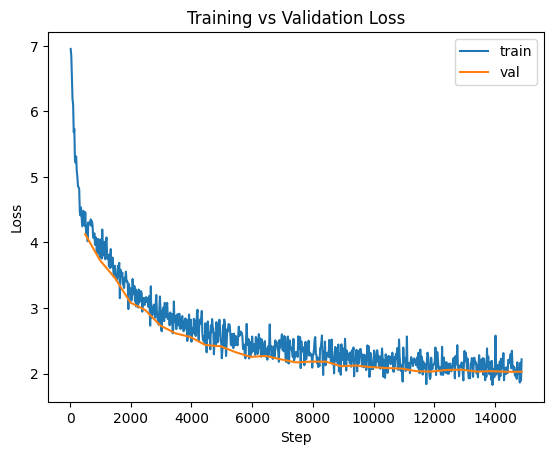

In [34]:

#logs = trainer.state.log_history
df = pd.DataFrame(logs)

train_loss = df[df["loss"].notna()]
val_loss = df[df["eval_loss"].notna()]

plt.plot(train_loss["step"], train_loss["loss"], label="train")
plt.plot(val_loss["step"], val_loss["eval_loss"], label="val")
plt.legend()
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.show()

In [35]:
import torch
import numpy as np
import pandas as pd
from torchvision.ops import box_iou
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
from scipy.optimize import linear_sum_assignment


@torch.no_grad()
def evaluate_detr_dataset_v6_hungarian(
    model,
    dataloader,
    image_processor,
    device,
    id2label,
    iou_threshold=0.5,
    score_threshold=0.3,   # changed from 0.05 to 0.3
):
    model.eval()
    model.to(device)

    total_predictions = 0
    total_gt = 0
    total_matches = 0
    correct_matches = 0
    sum_matched_iou = 0.0

    y_true = []
    y_pred = []

    for batch in dataloader:
        pixel_values = batch["pixel_values"].to(device)

        pixel_mask = batch.get("pixel_mask", None)
        if pixel_mask is not None:
            pixel_mask = pixel_mask.to(device)

        labels = [
            {k: v.to(device) for k, v in target.items()}
            for target in batch["labels"]
        ]

        outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask)

        target_sizes = torch.stack([
            target["orig_size"].to(device)
            for target in labels
        ])

        results = image_processor.post_process_object_detection(
            outputs,
            threshold=score_threshold,
            target_sizes=target_sizes
        )

        for result, target in zip(results, labels):
            pred_boxes = result["boxes"]
            pred_labels = result["labels"]

            true_boxes = target["boxes"]
            true_labels = target["class_labels"]

            h, w = target["orig_size"]

            true_boxes_xyxy = torch.zeros_like(true_boxes)

            if true_boxes.numel() > 0:
                cx = true_boxes[:, 0] * w
                cy = true_boxes[:, 1] * h
                bw = true_boxes[:, 2] * w
                bh = true_boxes[:, 3] * h

                true_boxes_xyxy[:, 0] = cx - bw / 2
                true_boxes_xyxy[:, 1] = cy - bh / 2
                true_boxes_xyxy[:, 2] = cx + bw / 2
                true_boxes_xyxy[:, 3] = cy + bh / 2

            num_preds = len(pred_boxes)
            num_gt = len(true_boxes_xyxy)

            total_predictions += num_preds
            total_gt += num_gt

            if num_preds == 0 or num_gt == 0:
                continue

            ious = box_iou(pred_boxes, true_boxes_xyxy)

            cost_matrix = (-ious).detach().cpu().numpy()
            pred_indices, gt_indices = linear_sum_assignment(cost_matrix)

            for pred_idx, gt_idx in zip(pred_indices, gt_indices):
                iou = ious[pred_idx, gt_idx].item()

                if iou < iou_threshold:
                    continue

                total_matches += 1
                sum_matched_iou += iou

                gt_label = int(true_labels[gt_idx].item())
                pred_label = int(pred_labels[pred_idx].item())

                y_true.append(gt_label)
                y_pred.append(pred_label)

                if pred_label == gt_label:
                    correct_matches += 1

    # --------------------------------------------------
    # Confusion matrix: matched boxes only
    # --------------------------------------------------
    label_ids = sorted(id2label.keys())
    label_names = [id2label[i] for i in label_ids]

    cm = confusion_matrix(y_true, y_pred, labels=label_ids)

    cm_df = pd.DataFrame(
        cm,
        index=[f"true_{name}" for name in label_names],
        columns=[f"pred_{name}" for name in label_names],
    )

    # --------------------------------------------------
    # A) Matched-only classification metrics
    # These match the confusion matrix.
    # They ignore unmatched GT and unmatched predictions.
    # --------------------------------------------------
    matched_accuracy = accuracy_score(y_true, y_pred) if len(y_true) > 0 else 0.0

    matched_precision_micro = precision_score(
        y_true, y_pred, labels=label_ids, average="micro", zero_division=0
    )

    matched_recall_micro = recall_score(
        y_true, y_pred, labels=label_ids, average="micro", zero_division=0
    )

    matched_f1_micro = f1_score(
        y_true, y_pred, labels=label_ids, average="micro", zero_division=0
    )

    matched_precision_macro = precision_score(
        y_true, y_pred, labels=label_ids, average="macro", zero_division=0
    )

    matched_recall_macro = recall_score(
        y_true, y_pred, labels=label_ids, average="macro", zero_division=0
    )

    matched_f1_macro = f1_score(
        y_true, y_pred, labels=label_ids, average="macro", zero_division=0
    )

    # --------------------------------------------------
    # B) Detection metrics including unmatched GT/preds
    # --------------------------------------------------
    unmatched_predictions = total_predictions - total_matches
    unmatched_gt = total_gt - total_matches
    wrong_class_matches = total_matches - correct_matches

    # Class-aware detection:
    # correct class + IoU match = TP
    # unmatched predictions + wrong-class matched preds = FP
    # unmatched GT + wrong-class matched GT = FN
    tp = correct_matches
    fp = unmatched_predictions + wrong_class_matches
    fn = unmatched_gt + wrong_class_matches

    detection_precision = tp / max(tp + fp, 1)
    detection_recall = tp / max(tp + fn, 1)
    detection_f1 = (
        2 * detection_precision * detection_recall /
        max(detection_precision + detection_recall, 1e-8)
    )

    # Localization-only detection:
    # ignores class correctness, only asks whether a GT was localized
    localization_precision = total_matches / max(total_predictions, 1)
    localization_recall = total_matches / max(total_gt, 1)
    localization_f1 = (
        2 * localization_precision * localization_recall /
        max(localization_precision + localization_recall, 1e-8)
    )

    mean_iou_matched = sum_matched_iou / max(total_matches, 1)

    print("===== DETR Dataset Evaluation V6: Hungarian Matching =====")
    print(f"IoU threshold: {iou_threshold}")
    print(f"Score threshold: {score_threshold}")
    print()
    print(f"Total predictions above threshold: {total_predictions}")
    print(f"Total ground-truth boxes: {total_gt}")
    print(f"Total matched pairs: {total_matches}")
    print(f"Correct class matched pairs: {correct_matches}")
    print(f"Unmatched predictions / FP candidates: {unmatched_predictions}")
    print(f"Unmatched GT / FN candidates: {unmatched_gt}")
    print(f"Wrong-class matched pairs: {wrong_class_matches}")
    print(f"Mean IoU of matched pairs: {mean_iou_matched:.4f}")

    print("\n---- A) Matched-only classification metrics ----")
    print("These match the confusion matrix and ignore unmatched GT/predictions.")
    print(f"Matched Accuracy:        {matched_accuracy:.4f}")
    print(f"Matched Precision micro: {matched_precision_micro:.4f}")
    print(f"Matched Recall micro:    {matched_recall_micro:.4f}")
    print(f"Matched F1 micro:        {matched_f1_micro:.4f}")
    print(f"Matched Precision macro: {matched_precision_macro:.4f}")
    print(f"Matched Recall macro:    {matched_recall_macro:.4f}")
    print(f"Matched F1 macro:        {matched_f1_macro:.4f}")

    print("\n---- B) Detection metrics including unmatched GT/predictions ----")
    print("These are stricter and should be used as real detection metrics.")
    print(f"Class-aware Precision: {detection_precision:.4f}")
    print(f"Class-aware Recall:    {detection_recall:.4f}")
    print(f"Class-aware F1:        {detection_f1:.4f}")

    print("\n---- C) Localization-only metrics ----")
    print("These ignore class correctness.")
    print(f"Localization Precision: {localization_precision:.4f}")
    print(f"Localization Recall:    {localization_recall:.4f}")
    print(f"Localization F1:        {localization_f1:.4f}")

    print("\nConfusion Matrix on Matched Boxes:")
    print(cm_df)

    return {
        "confusion_matrix_df": cm_df,
        "confusion_matrix": cm,

        "matched_accuracy": matched_accuracy,
        "matched_precision_micro": matched_precision_micro,
        "matched_recall_micro": matched_recall_micro,
        "matched_f1_micro": matched_f1_micro,
        "matched_precision_macro": matched_precision_macro,
        "matched_recall_macro": matched_recall_macro,
        "matched_f1_macro": matched_f1_macro,

        "class_aware_precision": detection_precision,
        "class_aware_recall": detection_recall,
        "class_aware_f1": detection_f1,

        "localization_precision": localization_precision,
        "localization_recall": localization_recall,
        "localization_f1": localization_f1,

        "mean_iou_matched": mean_iou_matched,
        "total_predictions": total_predictions,
        "total_gt": total_gt,
        "total_matches": total_matches,
        "correct_matches": correct_matches,
        "unmatched_predictions": unmatched_predictions,
        "unmatched_gt": unmatched_gt,
        "wrong_class_matches": wrong_class_matches,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "y_true": y_true,
        "y_pred": y_pred,
    }

In [36]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
val_metrics = evaluate_detr_dataset_v6_hungarian(
    model=model,
    dataloader=val_dataloader,
    image_processor=processor,
    device=device,
    id2label=model.config.id2label,
    iou_threshold=0.5,
    score_threshold=0.3
)

val_metrics["confusion_matrix_df"]


In [ ]:

# ============================================================
# INFERENCE
# ============================================================

def draw_boxes(image, boxes, labels, color, width=2):
    draw = ImageDraw.Draw(image)

    for box, label in zip(boxes, labels):
        x1, y1, x2, y2 = box
        draw.rectangle([x1, y1, x2, y2], outline=color, width=width)
        draw.text((x1, y1), label, fill=color)

    return image


def predict_and_draw(
    image_path,
    model,
    processor,
    id2label,
    gt_boxes=None,        # list of [x1,y1,x2,y2]
    gt_labels=None,       # list of class ids
    threshold=0.5,
    device=None
):
    if device is None:
        if torch.cuda.is_available():
            device = "cuda"
        elif torch.backends.mps.is_available():
            device = "mps"
        else:
            device = "cpu"

    model.to(device)
    model.eval()

    image = Image.open(image_path).convert("RGB")

    # -------- Prediction --------
    inputs = processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    target_sizes = torch.tensor([image.size[::-1]], device=device)

    results = processor.post_process_object_detection(
        outputs=outputs,
        threshold=threshold,
        target_sizes=target_sizes
    )[0]

    pred_boxes = results["boxes"].cpu().numpy()
    pred_labels = results["labels"].cpu().numpy()
    pred_scores = results["scores"].cpu().numpy()

    pred_label_names = [
        f"{id2label[int(l)]}:{round(float(s),2)}"
        for l, s in zip(pred_labels, pred_scores)
    ]
    print(len(pred_boxes),len(gt_boxes))
    print(pred_scores)
    # -------- Draw --------
    image_draw = image.copy()

    # Draw ground truth (GREEN)
    if gt_boxes is not None and len(gt_boxes) > 0:
        gt_label_names = [id2label[int(l)] for l in gt_labels]
        image_draw = draw_boxes(image_draw, gt_boxes, gt_label_names, color="green")

    # Draw predictions (RED)
    image_draw = draw_boxes(image_draw, pred_boxes, pred_label_names, color="red")

    return image_draw

In [ ]:
# Run test on single test image
#test
xml_path = '/content/data/Annotations/220105_A095_3.xml'
image_path = "/content/data/Images/220105_A095_3.jpg"
parsed = parse_voc_xml(xml_path, label2id)

gt_boxes = [obj["bbox_xyxy"] for obj in parsed["objects"]]
gt_labels = [obj["class_id"] for obj in parsed["objects"]]

img = predict_and_draw(
    image_path,
    model,
    processor,
    id2label,
    gt_boxes=gt_boxes,
    gt_labels=gt_labels,
    threshold=0.55
)

img.show()

In [ ]:
img

In [ ]:
#miss alignments:
xml_path = '/content/data/Annotations/220105_A095_3.xml'
image_path = "/content/data/Images/220105_A095_3.jpg"
parsed = parse_voc_xml(xml_path, label2id)
gt_boxes = [obj["bbox_xyxy"] for obj in parsed["objects"]]
gt_labels = [obj["class_id"] for obj in parsed["objects"]]
gt_label_names = [id2label[int(l)] for l in gt_labels]
image = Image.open(image_path).convert("RGB")
def draw_boxes(image, boxes, labels, color, width=2):
    draw = ImageDraw.Draw(image)

    for box, label in zip(boxes, labels):
        x1, y1, x2, y2 = box
        draw.rectangle([x1, y1, x2, y2], outline=color, width=width)
        draw.text((x1, y1), label, fill=color)

    return image
draw_boxes(image,gt_boxes,gt_label_names,'green')
image

In [ ]:
import torch
from PIL import Image, ImageDraw

def debug_detr_box_resize_back(image_path, model, processor, id2label, threshold=0.05, device=None):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

    model.to(device).eval()

    image = Image.open(image_path).convert("RGB")
    W, H = image.size

    inputs = processor(images=image, return_tensors="pt").to(device)

    print("Original image size W,H:", W, H)
    print("Processor pixel_values shape:", inputs["pixel_values"].shape)

    with torch.no_grad():
        outputs = model(**inputs)

    print("Raw DETR pred_boxes range:", outputs.pred_boxes.min().item(), outputs.pred_boxes.max().item())
    print("Raw DETR pred_boxes format: normalized cxcywh")

    # correct: target_sizes expects [height, width]
    target_sizes = torch.tensor([[H, W]], device=device)

    results = processor.post_process_object_detection(
        outputs=outputs,
        threshold=threshold,
        target_sizes=target_sizes
    )[0]

    boxes = results["boxes"].cpu()
    labels = results["labels"].cpu()
    scores = results["scores"].cpu()

    print("Post-processed boxes shape:", boxes.shape)
    print("Post-processed x range:", boxes[:, [0, 2]].min().item(), boxes[:, [0, 2]].max().item())
    print("Post-processed y range:", boxes[:, [1, 3]].min().item(), boxes[:, [1, 3]].max().item())

    print("\nFirst 10 boxes:")
    for i in range(min(10, len(boxes))):
        print(
            i,
            boxes[i].tolist(),
            id2label[int(labels[i])],
            float(scores[i])
        )

    img = image.copy()
    draw = ImageDraw.Draw(img)

    for box, label, score in zip(boxes, labels, scores):
        x1, y1, x2, y2 = box.tolist()
        draw.rectangle([x1, y1, x2, y2], outline="red", width=2)
        draw.text((x1, y1), f"{id2label[int(label)]}:{float(score):.2f}", fill="red")

    return img, boxes, labels, scores

In [ ]:
img, boxes, labels, scores = debug_detr_box_resize_back(
    image_path=image_path,
    model=model,
    processor=processor,
    id2label=model.config.id2label,
    threshold=0.05,
    device=device
)

img

In [ ]:

def predict_match_and_draw(
    image_path,
    model,
    processor,
    id2label,
    gt_boxes,
    gt_labels,
    score_threshold=0.5,
    iou_threshold=0.5,
    device=None,
    draw=True
):
    """
    End-to-end:
    image → prediction → GT-centered one-to-one matching

    Matching rules:
    1. Prefer same-class predictions
    2. Else fallback to any prediction
    3. Choose highest IoU (tie → higher score)
    4. No repeated predictions
    """

    # ---------------- device ----------------
    if device is None:
        if torch.cuda.is_available():
            device = "cuda"
        elif torch.backends.mps.is_available():
            device = "mps"
        else:
            device = "cpu"

    model.to(device)
    model.eval()

    # ---------------- load image ----------------
    image = Image.open(image_path).convert("RGB")

    # ---------------- prediction ----------------
    inputs = processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    target_sizes = torch.tensor([image.size[::-1]], device=device)

    results = processor.post_process_object_detection(
        outputs=outputs,
        threshold=score_threshold,
        target_sizes=target_sizes
    )[0]

    pred_boxes = results["boxes"].cpu()
    pred_labels = results["labels"].cpu()
    pred_scores = results["scores"].cpu()

    # ---------------- matching ----------------
    gt_boxes = torch.tensor(gt_boxes, dtype=torch.float)
    gt_labels = torch.tensor(gt_labels, dtype=torch.long)

    matches = []

    if len(pred_boxes) == 0:
        for i in range(len(gt_boxes)):
            matches.append({
                "gt_idx": i,
                "gt_label": int(gt_labels[i]),
                "pred_idx": None,
                "matched": False
            })
        return image, matches

    ious = box_iou(gt_boxes, pred_boxes)
    used_preds = set()

    for gt_idx in range(len(gt_boxes)):
        gt_label = gt_labels[gt_idx]

        available = [
            j for j in range(len(pred_boxes))
            if j not in used_preds
        ]

        if len(available) == 0:
            matches.append({
                "gt_idx": int(gt_idx),
                "gt_label": int(gt_label),
                "pred_idx": None,
                "matched": False
            })
            continue

        same_class = [
            j for j in available
            if pred_labels[j] == gt_label
        ]

        # rule 1: same-class first, else fallback
        candidates = same_class if len(same_class) > 0 else available
        candidates = torch.tensor(candidates)

        candidate_ious = ious[gt_idx, candidates]
        candidate_scores = pred_scores[candidates]

        # rule 2 + 3: max IoU, tie → score
        ranking = candidate_ious + 1e-6 * candidate_scores
        best_idx = torch.argmax(ranking)

        pred_idx = int(candidates[best_idx])
        best_iou = float(ious[gt_idx, pred_idx])

        if best_iou >= iou_threshold:
            used_preds.add(pred_idx)

            matches.append({
                "gt_idx": int(gt_idx),
                "gt_label": int(gt_label),
                "pred_idx": pred_idx,
                "pred_label": int(pred_labels[pred_idx]),
                "score": float(pred_scores[pred_idx]),
                "iou": best_iou,
                "matched": True
            })
        else:
            matches.append({
                "gt_idx": int(gt_idx),
                "gt_label": int(gt_label),
                "pred_idx": None,
                "matched": False,
                "iou": best_iou
            })

    # ---------------- drawing ----------------
    if not draw:
        return image, matches

    image_draw = image.copy()
    draw_obj = ImageDraw.Draw(image_draw)

    # draw GT (green)
    for box, label in zip(gt_boxes, gt_labels):
        x1, y1, x2, y2 = box.tolist()
        draw_obj.rectangle([x1, y1, x2, y2], outline="green", width=2)
        draw_obj.text((x1, y1), f"GT:{id2label[int(label)]}", fill="green")

    # draw matched predictions (red)
    for m in matches:
        if m["matched"]:
            box = pred_boxes[m["pred_idx"]].tolist()
            x1, y1, x2, y2 = box

            label = id2label[m["pred_label"]]
            score = m["score"]

            draw_obj.rectangle([x1, y1, x2, y2], outline="red", width=2)
            draw_obj.text(
                (x1, y1),
                f"P:{label}:{score:.2f}",
                fill="red"
            )

    return image_draw, matches

In [ ]:
#test
xml_path = '/content/data/Annotations/220105_A095_2.xml'
image_path = "/content/data/Images/220105_A095_2.jpg"
parsed = parse_voc_xml(xml_path, label2id)

gt_boxes = [obj["bbox_xyxy"] for obj in parsed["objects"]]
gt_labels = [obj["class_id"] for obj in parsed["objects"]]

img, matches = predict_match_and_draw(
    image_path=image_path,
    model=model,
    processor=processor,
    id2label=model.config.id2label,
    gt_boxes=gt_boxes,
    gt_labels=gt_labels,
    score_threshold=0.05,
    iou_threshold=0.5
)

img

# Further work:

1. The model defaults to predicting the premium class, likely due to class imbalance. Further tuning is needed to address this issue.
2. Further tuning for better box detection

# Advanced EDA

#### 1. FFT: light brightness variation

Low frequency blob indicates that there is brightness variation

In [ ]:
#FFT
#Lighting brightness
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

img_files= [image_path]

plt.figure(figsize=(15, 12))

for i, fname in enumerate(img_files):
    path = os.path.join('FDU_HairFollicleDataset/images/', fname)

    # Load + grayscale
    img_color = cv2.imread(path)
    img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

    # FFT
    f = np.fft.fft2(img_gray)
    fshift = np.fft.fftshift(f)
    magnitude = np.log(1 + np.abs(fshift))

    # Normalize (optional but better visualization)
    magnitude = magnitude / magnitude.max()

    # Plot original
    plt.subplot(10, 2, 2*i + 1)
    plt.imshow(img_gray, cmap='gray')
    plt.title(f"{fname}")
    plt.axis('off')

    # Plot FFT
    plt.subplot(10, 2, 2*i + 2)
    plt.imshow(magnitude, cmap='inferno')
    plt.title("FFT")
    plt.axis('off')

plt.tight_layout()
plt.show()

#### 2. Merging overlapping boxes

In [ ]:
def box_area(box):
    x1, y1, x2, y2 = box
    return max(0, x2 - x1) * max(0, y2 - y1)

def intersection_area(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b

    ix1 = max(ax1, bx1)
    iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)
    #print(ix2 - ix1,iy2 - iy1)
    return max(0, ix2 - ix1) * max(0, iy2 - iy1)

def overlap_over_smaller(a, b):
    #print(a,b)
    inter = intersection_area(a, b)
    #print(inter)
    small_area = min(box_area(a), box_area(b))

    if small_area == 0:
        return 0
    #print(inter/small_area )
    return inter / small_area

def merge_two_boxes(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b

    return [
        min(ax1, bx1),
        min(ay1, by1),
        max(ax2, bx2),
        max(ay2, by2)
    ]

def merge_overlapping_boxes(boxes, threshold=0.20):
    """
    boxes: list of [x1, y1, x2, y2]
    threshold: overlap / smaller_box_area threshold
    """

    boxes = [list(map(float, b)) for b in boxes]
    changed = True

    while changed:
        changed = False
        merged = []
        used = [False] * len(boxes)

        for i in range(len(boxes)):
            if used[i]:
                continue

            current = boxes[i]
            used[i] = True

            for j in range(i + 1, len(boxes)):
                if used[j]:
                    continue

                ratio = overlap_over_smaller(current, boxes[j])

                if ratio >= threshold:
                    current = merge_two_boxes(current, boxes[j])
                    used[j] = True
                    changed = True

            merged.append(current)

        boxes = merged

    return boxes

In [ ]:
import matplotlib.patches as patches
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(img)
for row in gt_boxes:
    rect = patches.Rectangle(
        (row[0], row[1]),
        row[2] - row[0],
        row[3] - row[1],
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    )
    ax.add_patch(rect)
    #ax.text(row[0], row[1], str(row["class"]), color="yellow", fontsize=8)

merged_boxes = merge_overlapping_boxes(gt_boxes, 0.2)
#print(len(boxes), len(merged_boxes))
for row in merged_boxes:
  rect = patches.Rectangle(
          (row[0], row[1]),
          row[2] - row[0],
          row[3] - row[1],
          linewidth=2,
          edgecolor="green",
          facecolor="none"
      )
  ax.add_patch(rect)
plt.axis("off")


# Data Aumentation

#### 1.High pass filter

The is low frequency blob indicating light brightness variation. We can apply high pass filter to generate images for data augmentation.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

import cv2
import numpy as np
import matplotlib.pyplot as plt

def fft_highpass_enhanced_color(
    image_path,
    radius=25,
    blend_original=0.65,
    blend_highpass=0.75,
    beta=10,
    use_clahe=True
):
    """
    FFT high-pass enhancement on luminance channel, returned as color image.
    Keeps color while enhancing edges/follicle structures.
    """

    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise FileNotFoundError(f"Cannot read image: {image_path}")

    # Convert to LAB so we only modify brightness/structure
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    L, A, B = cv2.split(lab)

    # FFT on L channel
    f = np.fft.fft2(L)
    fshift = np.fft.fftshift(f)

    h, w = L.shape
    cy, cx = h // 2, w // 2

    # Circular high-pass mask
    y, x = np.ogrid[:h, :w]
    dist = np.sqrt((x - cx) ** 2 + (y - cy) ** 2)

    mask = np.ones((h, w), dtype=np.float32)
    mask[dist <= radius] = 0

    # Apply high-pass filter
    fshift_filtered = fshift * mask

    # Inverse FFT
    L_hp = np.fft.ifft2(np.fft.ifftshift(fshift_filtered))
    L_hp = np.abs(L_hp)

    # Normalize high-pass result to visible range
    L_hp = cv2.normalize(L_hp, None, 0, 255, cv2.NORM_MINMAX)
    L_hp = L_hp.astype(np.uint8)

    # Optional contrast enhancement
    if use_clahe:
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        L_hp = clahe.apply(L_hp)

    # Blend original luminance + high-pass detail
    L_enhanced = cv2.addWeighted(
        L,
        blend_original,
        L_hp,
        blend_highpass,
        beta
    )

    L_enhanced = np.clip(L_enhanced, 0, 255).astype(np.uint8)

    # Merge back color channels
    lab_enhanced = cv2.merge([L_enhanced, A, B])
    enhanced_bgr = cv2.cvtColor(lab_enhanced, cv2.COLOR_LAB2BGR)

    return enhanced_bgr

In [ ]:

enhanced_bgr = fft_highpass_enhanced_color(
    image_path,
    radius=25,
    blend_original=0.65,
    blend_highpass=0.75,
    beta=10,
    use_clahe=True
)

original_bgr = cv2.imread(image_path)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(enhanced_bgr, cv2.COLOR_BGR2RGB))
plt.title("FFT High-Pass Enhanced Color")
plt.axis("off")

plt.show()

### 2. Edge enhancement

In [ ]:
import cv2
import numpy as np

def edge_enhance_color(img_bgr):
    # Convert color image to LAB
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    L, A, B = cv2.split(lab)

    # Mild denoise
    L_blur = cv2.GaussianBlur(L, (0, 0), sigmaX=1.0)

    # Unsharp mask: enhance edges
    L_sharp = cv2.addWeighted(L, 1.7, L_blur, -0.7, 0)

    # Optional contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    L_enhanced = clahe.apply(L_sharp)

    # Merge back with original color channels
    lab_out = cv2.merge([L_enhanced, A, B])
    img_out = cv2.cvtColor(lab_out, cv2.COLOR_LAB2BGR)

    return img_out

In [ ]:
img = cv2.imread(image_path)
enhanced = edge_enhance_color(img)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB))
plt.title("Edge Enhanced")
plt.axis("off")

plt.show()